# Protocol 2: Large-Scale Molecular Assembly Analysis

This notebook follows the workflow behind Figure 2b of [Marshall et al. (2021)](https://doi.org/10.1038/s41467-021-23258-x).

It samples 10,000 molecules from the CBRDB database, computes their assembly indices in parallel, and visualises assembly index against molecular weight as a density heatmap and a grid of example structures. It then runs the same workflow on a random sample drawn from PubChem and compares the two datasets on shared axes, and finishes with a worked example of running the workflow on your own molecules instead of a sampled database.

## Running it

Run this notebook from its own directory so the figures it saves land beside
it. In JupyterLab:

```bash
cd examples/protocols/2
jupyter lab protocol_2.ipynb
```

Or headlessly, which is how the committed outputs were produced:

```bash
cd examples/protocols/2
jupyter nbconvert --to notebook --execute --inplace protocol_2.ipynb
```

Use **Run All** so the total-time cell at the end measures the whole workflow.

This is the longest-running protocol. It needs network access: it downloads the CBRDB dataset on the first run and queries PubChem's PUG REST service for the PubChem sample. It also uses every CPU core. Expect roughly 3–5 minutes at the default sizes, most of it waiting on PubChem. Lower `N_SAMPLES` and `N_PUBCHEM` for a quick look; see the [parallel calculations guide](https://assemblytheorytools.readthedocs.io/en/latest/guide/parallel.html) for tuning the worker count.

## Timing

The heavy steps below start with the `%%time` cell magic. Read the **Wall
time** it reports. The parallel steps spread work across every CPU core, and
`%%time` counts CPU time for the notebook's own process only, not the worker
pool, so wall time is the figure to compare. Expect a few minutes at the
default sample sizes. The times shown were recorded on a 28-core machine and
will differ on yours.

In [1]:
%matplotlib inline
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import assemblytheorytools as att

print(f"CPU cores available: {os.cpu_count()}")
_t_start = time.perf_counter()

CPU cores available: 28


## Parameters

In [2]:
# Number of molecules to sample from CBRDB. The default reproduces the paper;
# lower it (e.g. 1_000) for a quick run.
N_SAMPLES = 10_000

# Selection criteria shared by every dataset in this notebook: the CBRDB
# sample, the PubChem sample and your own molecules.
#   MAX_MW    - maximum molecular weight in Da (keep it a multiple of 10 so the
#               heatmap bands tile it exactly)
#   MAX_BONDS - maximum number of non-hydrogen bonds
MAX_MW = 350.0
MAX_BONDS = 40

# PubChem sample: N_PUBCHEM random compounds are fetched, then the criteria
# above are applied. Roughly half survive, so 2_000 gives about 1_000
# molecules. Fetching takes about 0.07 s per compound; lower it for a quick run.
N_PUBCHEM = 2_000
PUBCHEM_SEED = 42         # fixes which compound IDs are drawn
PUBCHEM_BATCH_SIZE = 100  # compound IDs per request, well inside PubChem's time limit

# Assembly-index settings shared by the parallel calculation:
#   strip_hydrogen - remove hydrogens before the search
#   timeout        - per-molecule limit in seconds
#   exact          - return -1 on timeout instead of an upper bound
AI_SETTINGS = {'strip_hydrogen': True, 'timeout': 120.0, 'exact': True}

# Molecule grid: only short nicknames are readable as labels.
MAX_NAME_LENGTH = 14
N_GRID = 9
N_COLS = 3

# Comparison: a 10 Da band needs at least this many molecules before its
# median assembly index is plotted.
MIN_PER_BAND = 5

### 1. Data acquisition

`att.sample_cbrdb` downloads the CBRDB dataset, keeps the molecules with
`molecular_weight <= MAX_MW` and at most `MAX_BONDS` non-hydrogen bonds, and
returns a random sample as a DataFrame with `smiles`, `molecular_weight` and
`nickname` columns.

In [3]:
%%time
sample = att.sample_cbrdb(n_samples=N_SAMPLES, max_mw=MAX_MW, max_bonds=MAX_BONDS)
sample.head()

CPU times: user 641 ms, sys: 107 ms, total: 748 ms
Wall time: 9.25 s


,compound_id,nickname,smiles,molecular_weight,n_heavy_atoms,n_bonds
0,C01186,"(3S,5S)-3,5-Diaminohexanoate",C[C@H](N)C[C@H](N)CC(=O)O,146.190,10,9
1,C18524,Empenthrin,C#CC(OC(=O)C1C(C=C(C)C)C1(C)C)/C(C)=C/CC,274.404,20,20
2,C21138,trans-2-Octenal,CCCCC/C=C/C=O,126.199,9,8
3,C19443,Methyl acrylate,C=CC(=O)OC,86.090,6,5
4,C16788,Pyriculol,C/C=C/[C@H](O)[C@H](O)/C=C/c1cccc(O)c1C=O,248.278,18,18


### 2. Parallel computation

Two parallel passes, timed separately. First convert every SMILES to a graph;
`att.mp_calc` maps a function across all cores. Because the worker pool pickles
the function by reference, `att.smi_to_nx` works here (it is importable from the
installed package), whereas a function defined in this notebook would not.

In [4]:
%%time
graphs = att.mp_calc(att.smi_to_nx, sample['smiles'])

CPU times: user 580 ms, sys: 77.8 ms, total: 658 ms
Wall time: 2.54 s


Then compute the assembly index of every graph in parallel.

In [5]:
%%time
sample['assembly_index'] = att.calculate_assembly_index_parallel(
    graphs, settings=AI_SETTINGS,
)[0]

CPU times: user 3.89 s, sys: 269 ms, total: 4.16 s
Wall time: 8.59 s


### 3. Data filtering

Keep only exact results with an assembly index of 1 or more. This drops the
timeouts (negative) and the valid but trivial zero-index case from the plotted
subset.

In [6]:
n_before = len(sample)
sample = sample[sample['assembly_index'] >= 1].reset_index(drop=True)
print(f"Kept {len(sample)} of {n_before} molecules (AI >= 1)")

Kept 9906 of 10000 molecules (AI >= 1)


### 4. Heatmap

A 2D density heatmap of assembly index against molecular weight. A density plot
is used instead of a scatter because 10,000 points would be unreadable as
markers.

The bin edges are set explicitly: one bin per 10 Da band up to `MAX_MW`, and one
bin centred on each integer assembly index up to the largest index in this
sample. Every heatmap later in the notebook reuses these edges, so the plots
share the same axes and bin sizes and can be compared directly.

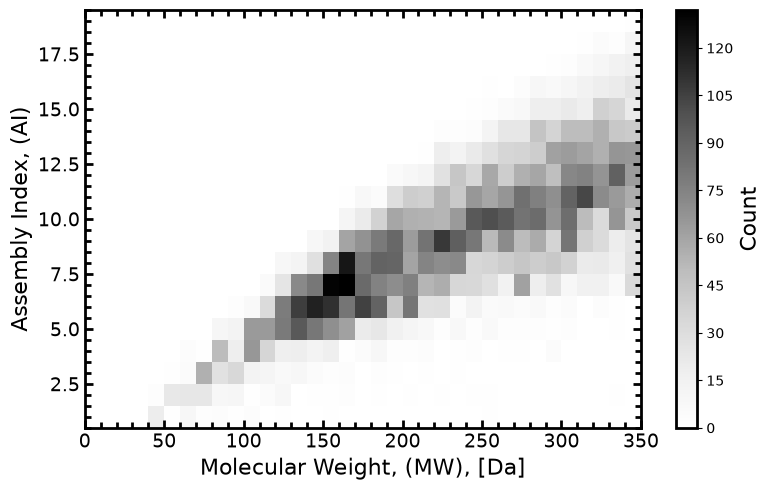

In [7]:
# Bin edges shared by every heatmap in this notebook: one x-bin per 10 Da band
# and one y-bin centred on each integer assembly index.
ai_max = int(sample['assembly_index'].max())
x_edges = np.arange(0, MAX_MW + 10, 10)
y_edges = np.arange(0.5, ai_max + 1.5, 1)

fig, ax = att.plot_heatmap(
    sample['molecular_weight'].to_numpy(),
    sample['assembly_index'].to_numpy(),
    "Molecular Weight, (MW), [Da]",
    "Assembly Index, (AI)",
    nbins=(x_edges, y_edges),
    c_map='Greys',
)
plt.savefig("assembly_index_heatmap.png", dpi=300)
plt.savefig("assembly_index_heatmap.svg")
plt.show()

*Assembly index against molecular weight across the sampled CBRDB molecules, as a density plot.*

### 5. Molecule grid

Pick nine short-named molecules, sort them by assembly index, and draw them on a
grid. Sorting once keeps each structure, label and index aligned.

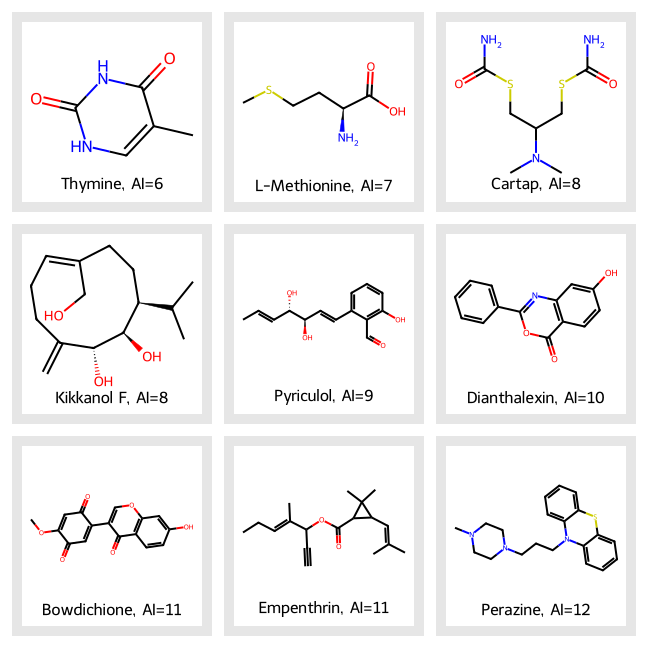

In [8]:
selected = sample[sample['nickname'].str.len() <= MAX_NAME_LENGTH].head(N_GRID)
selected = selected.sort_values('assembly_index').reset_index(drop=True)

labs = [f"{row.nickname}, AI={row.assembly_index}" for row in selected.itertuples()]
smis = selected['smiles'].tolist()

img = att.draw_mol_grid_box(
    smis, legends=labs, n_cols=N_COLS,
    sort_by=selected['assembly_index'].tolist(),
)
img.save("molecule_grid.png")
display(img)

*A subset of the analysed molecules with their nicknames and assembly indices, sorted by index.*

### 6. PubChem sample

The same workflow on a second source. `att.sample_random_pubchem` draws random
PubChem compound IDs, fetches them in batches from PubChem's PUG REST service
(so it needs network access and takes about 0.07 s per compound), and returns
the IDs and SMILES of the single-fragment molecules it found. Its own
`max_bonds` check counts every bond including hydrogens, so it is not the CBRDB
criterion; the shared criteria are applied afterwards with `att.filter_by_mw`
and `att.filter_by_nh_bonds`, which add `molecular_weight` and `n_bonds` columns
and return the rows that pass. About half of the raw sample survives.

The seed fixes which compound IDs are drawn, so the same IDs are requested on
every run and the sample only changes if PubChem's records change. If PubChem
is unreachable the call retries with fresh IDs rather than failing fast, so
interrupt the kernel if it makes no progress.

In [9]:
%%time
cids, smiles = att.sample_random_pubchem(
    N_PUBCHEM, seed=PUBCHEM_SEED, batch_size=PUBCHEM_BATCH_SIZE,
)
pubchem = pd.DataFrame({'cid': cids, 'smiles': smiles})
pubchem.head()

CPU times: user 1.17 s, sys: 103 ms, total: 1.28 s
Wall time: 1min 50s


,cid,smiles
0,85822413,C[Si](C)C1=CC=C(C=C1)C#CC2=CC=CC=C2
1,14942604,CC1=CC=C(C=C1)NC(=S)NC2=NC(=NC(=N2)NC3=CC4=C(C...
2,3356887,CC(C)(C(=O)OC)NC(=O)C=CSC1=CC=CC=C1
3,99529224,CC[C@H](C1=CC=CC=C1OCC(=O)NC)NC(=O)CC2=CSC(=N2...
4,36913811,C[C@@H](C1=CC=CC=C1Cl)N2CC[NH+](CC2)CC(=O)NN3C...


Apply the shared selection criteria, then the same two parallel passes and the
same AI >= 1 filter as for CBRDB.

In [10]:
%%time
n_before = len(pubchem)
pubchem = att.filter_by_mw(pubchem, max_mw=MAX_MW, c_mw='molecular_weight')
pubchem = att.filter_by_nh_bonds(pubchem, max_bonds=MAX_BONDS)
print(f"Kept {len(pubchem)} of {n_before} PubChem molecules "
      f"(MW <= {MAX_MW:g} Da and <= {MAX_BONDS} non-H bonds)")

graphs = att.mp_calc(att.smi_to_nx, pubchem['smiles'])
pubchem['assembly_index'] = att.calculate_assembly_index_parallel(
    graphs, settings=AI_SETTINGS,
)[0]

n_before = len(pubchem)
pubchem = pubchem[pubchem['assembly_index'] >= 1].reset_index(drop=True)
print(f"Kept {len(pubchem)} of {n_before} molecules (AI >= 1)")

Kept 966 of 2000 PubChem molecules (MW <= 350 Da and <= 40 non-H bonds)


Kept 966 of 966 molecules (AI >= 1)
CPU times: user 792 ms, sys: 95 ms, total: 887 ms
Wall time: 12.5 s


### 7. Comparison

First the PubChem heatmap on exactly the axes and bins of the CBRDB heatmap
above. Any PubChem molecule with an assembly index above the CBRDB range would
fall outside the shared bins, so the count of such molecules is printed.

PubChem molecules with AI above the CBRDB maximum of 19 (not shown): 0


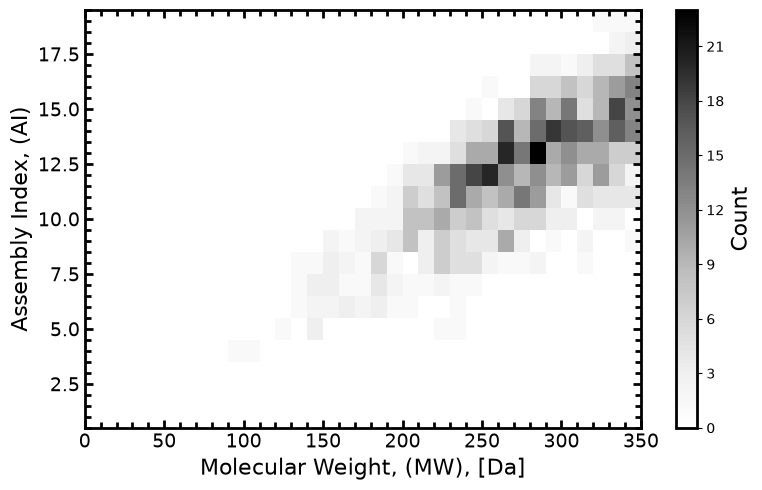

In [11]:
n_outside = int((pubchem['assembly_index'] > ai_max).sum())
print(f"PubChem molecules with AI above the CBRDB maximum of {ai_max} "
      f"(not shown): {n_outside}")

fig, ax = att.plot_heatmap(
    pubchem['molecular_weight'].to_numpy(),
    pubchem['assembly_index'].to_numpy(),
    "Molecular Weight, (MW), [Da]",
    "Assembly Index, (AI)",
    nbins=(x_edges, y_edges),
    c_map='Greys',
)
plt.savefig("assembly_index_heatmap_pubchem.png", dpi=300)
plt.savefig("assembly_index_heatmap_pubchem.svg")
plt.show()

*Assembly index against molecular weight across the sampled PubChem molecules, on the same axes and bins as the CBRDB heatmap.*

The two samples differ in size, so compare the trend rather than the counts:
the median assembly index in each 10 Da band, for both datasets on one set of
axes. Bands with fewer than `MIN_PER_BAND` molecules are left off.

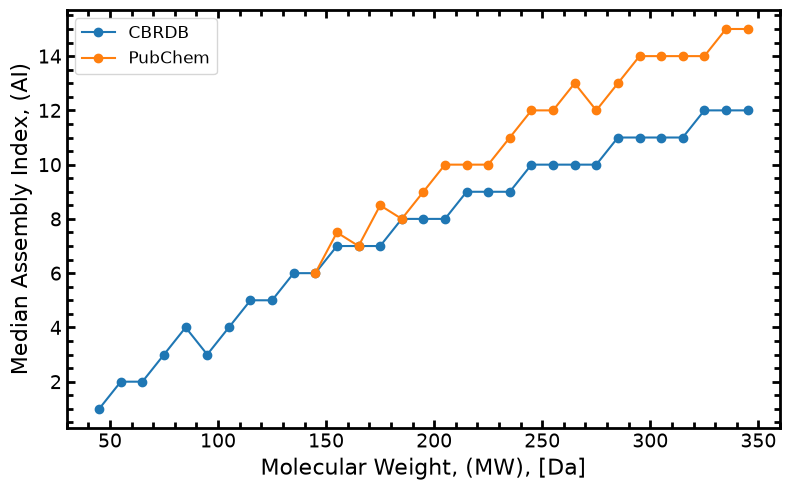

In [12]:
datasets = {'CBRDB': sample, 'PubChem': pubchem}

fig, ax = plt.subplots(figsize=(8, 5))
for label, df in datasets.items():
    band = (df['molecular_weight'] // 10 * 10).astype(int)
    grouped = df.groupby(band)['assembly_index']
    median_ai = grouped.median()[grouped.size() >= MIN_PER_BAND]
    ax.plot(median_ai.index + 5, median_ai.to_numpy(), marker='o', label=label)
ax.legend(fontsize=12)
att.ax_plot(fig, ax, "Molecular Weight, (MW), [Da]", "Median Assembly Index, (AI)",
            xs=16, ys=16)
plt.savefig("assembly_index_vs_mw_comparison.png", dpi=300)
plt.savefig("assembly_index_vs_mw_comparison.svg")
plt.show()

*Median assembly index per 10 Da molecular-weight band for the CBRDB and PubChem samples.*

Finally a summary table: sample size, median molecular weight, median assembly
index, and the Pearson correlation between molecular weight and assembly index
(`att.get_r`).

In [13]:
summary = pd.DataFrame(
    [
        {
            'dataset': label,
            'n': len(df),
            'median MW [Da]': df['molecular_weight'].median(),
            'median AI': df['assembly_index'].median(),
            'Pearson r (MW, AI)': att.get_r(df['molecular_weight'], df['assembly_index']),
        }
        for label, df in datasets.items()
    ]
).set_index('dataset')
summary.round(2)

,n,median MW [Da],median AI,"Pearson r (MW, AI)"
dataset,,,,
CBRDB,9906,234.34,9.0,0.78
PubChem,966,278.38,12.0,0.73


### 8. Using your own data

`att.sample_cbrdb` and `att.sample_random_pubchem` are conveniences: each just
returns a table with a `smiles` column. Nothing downstream depends on where the
SMILES came from, so the same workflow runs unchanged on your own molecules.
Build a DataFrame with a `smiles` column, either from a list in the notebook or
from a CSV file, and follow the same steps: the shared filters, the two parallel
passes and the AI >= 1 filter. A `name` column is optional and is only used for
labels.

The list below includes cholesterol (386.7 Da), which the `MAX_MW` filter
removes, so you can see the filter act. Ten molecules take a few seconds; the
same code scales to thousands.

In [14]:
my_data = pd.DataFrame({
    'name': [
        'Ethanol', 'Benzene', 'Paracetamol', 'Nicotine', 'Glucose',
        'Caffeine', 'Ibuprofen', 'Morphine', 'Penicillin G', 'Cholesterol',
    ],
    'smiles': [
        'CCO',
        'c1ccccc1',
        'CC(=O)Nc1ccc(O)cc1',
        'CN1CCC[C@H]1c1cccnc1',
        'OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O',
        'Cn1cnc2c1c(=O)n(C)c(=O)n2C',
        'CC(C)Cc1ccc(cc1)C(C)C(=O)O',
        'CN1CC[C@]23c4c5ccc(O)c4O[C@H]2[C@@H](O)C=C[C@H]3[C@H]1C5',
        'CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@H]1C(=O)O',
        'C[C@H](CCCC(C)C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3[C@H]2CC=C4[C@@]3(CC[C@@H](C4)O)C)C',
    ],
})
# my_data = pd.read_csv("my_molecules.csv")  # any table with a 'smiles' column

n_before = len(my_data)
my_data = att.filter_by_mw(my_data, max_mw=MAX_MW, c_mw='molecular_weight')
my_data = att.filter_by_nh_bonds(my_data, max_bonds=MAX_BONDS)
print(f"Kept {len(my_data)} of {n_before} molecules "
      f"(MW <= {MAX_MW:g} Da and <= {MAX_BONDS} non-H bonds)")

graphs = att.mp_calc(att.smi_to_nx, my_data['smiles'])
my_data['assembly_index'] = att.calculate_assembly_index_parallel(
    graphs, settings=AI_SETTINGS,
)[0]
my_data = my_data[my_data['assembly_index'] >= 1]
my_data = my_data.sort_values('assembly_index').reset_index(drop=True)
my_data

Kept 9 of 10 molecules (MW <= 350 Da and <= 40 non-H bonds)


,name,smiles,molecular_weight,n_bonds,assembly_index
0,Ethanol,CCO,46.069,2,1
1,Benzene,c1ccccc1,78.114,6,3
2,Glucose,OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O,180.156,12,6
3,Paracetamol,CC(=O)Nc1ccc(O)cc1,151.165,11,8
4,Ibuprofen,CC(C)Cc1ccc(cc1)C(C)C(=O)O,206.285,15,8
5,Caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C,194.194,15,9
6,Nicotine,CN1CCC[C@H]1c1cccnc1,162.236,13,10
7,Morphine,CN1CC[C@]23c4c5ccc(O)c4O[C@H]2[C@@H](O)C=C[C@H...,285.343,25,13
8,Penicillin G,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,334.397,25,14


Draw the molecules on a grid, labelled with their names and assembly indices,
then mark them on the CBRDB heatmap to see where they sit relative to the
database.

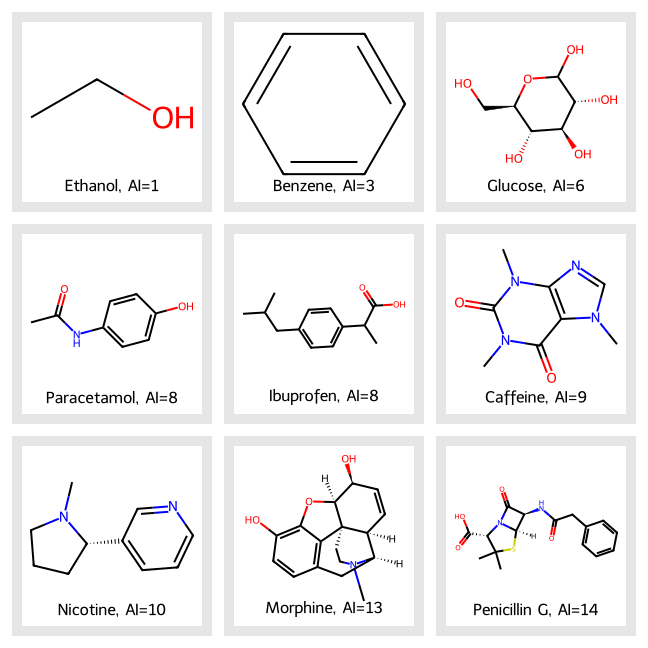

In [15]:
labs = [f"{name}, AI={ai}" for name, ai in zip(my_data['name'], my_data['assembly_index'])]

img = att.draw_mol_grid_box(my_data['smiles'].tolist(), legends=labs, n_cols=N_COLS)
img.save("molecule_grid_own_data.png")
display(img)

*Your own molecules with their assembly indices, sorted by index.*

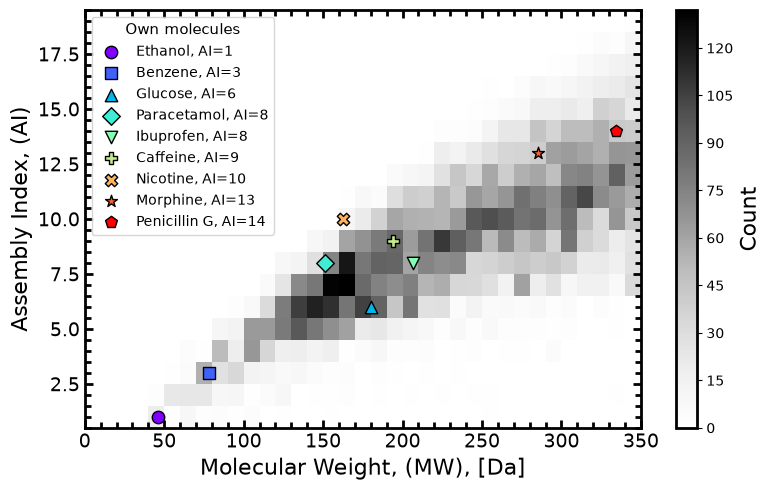

In [16]:
fig, ax = att.plot_heatmap(
    sample['molecular_weight'].to_numpy(),
    sample['assembly_index'].to_numpy(),
    "Molecular Weight, (MW), [Da]",
    "Assembly Index, (AI)",
    nbins=(x_edges, y_edges),
    c_map='Greys',
)
# One marker per molecule, named in the legend, so the labels never overlap
# however close together the molecules sit.
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'p']
colors = plt.cm.rainbow(np.linspace(0, 1, len(my_data)))
for i, (name, mw, ai) in enumerate(
        zip(my_data['name'], my_data['molecular_weight'], my_data['assembly_index'])):
    ax.scatter(mw, ai, s=80, marker=markers[i % len(markers)], color=colors[i],
               edgecolor='black', zorder=3, label=f"{name}, AI={ai}")
# imshow fixes the axis limits to the bin edges; widen them if a molecule sits
# above the top bin.
ax.set_ylim(top=max(y_edges[-1], my_data['assembly_index'].max() + 0.5))
ax.legend(loc='upper left', fontsize=10, title='Own molecules', title_fontsize=11)
plt.savefig("assembly_index_heatmap_own_data.png", dpi=300)
plt.savefig("assembly_index_heatmap_own_data.svg")
plt.show()

*The CBRDB heatmap with your own molecules marked; the legend lists their names and assembly indices.*

In [17]:
print(f"Total wall time: {time.perf_counter() - _t_start:.1f} s")

Total wall time: 153.0 s


## Related documentation

* [Parallel calculations](https://assemblytheorytools.readthedocs.io/en/latest/guide/parallel.html) — `mp_calc` and `calculate_assembly_index_parallel`.
* [Complexity scores](https://assemblytheorytools.readthedocs.io/en/latest/guide/complexity.html) — comparing assembly index with other measures.
* [Data helpers](https://assemblytheorytools.readthedocs.io/en/latest/api/tools_data.html) — `sample_cbrdb`, `sample_random_pubchem`, `filter_by_mw` and `filter_by_nh_bonds`.